In [1]:
import datetime
import http
import json
import pathlib
import re
import os
import subprocess

import cycler
from IPython.display import display, Markdown
import matplotlib.pyplot
import numpy
import polars
from tqdm.notebook import tqdm

EVALUATION_DIR = pathlib.Path.cwd() / "06_1evaluation"
os.environ["EVALUATION_DIR"] = str(EVALUATION_DIR)

##### Terminal 1 (on remote proxy host)

```console
$ cd 06_1evaluation  # TBD reflect rename
$ script -fq output-dataset/docker-compose-remote-$(date "+%s").log
$ ./start_remote_setup.sh up
...
 ✔ Network 06_1evaluation_remote           Created                                                                                    0.1s
 ✔ Container 06_1evaluation-remote-proxy-1 Created                                                                                    0.1s
Attaching to remote-proxy-1
```

##### Terminal 2 (on local proxy host)

```console
$ cd 06_1evaluation  # TBD reflect rename
$ script -fq output-dataset/docker-compose-local-$(date "+%s").log
$ TRANCO_LOWER_LIMIT=0 TRANCO_UPPER_LIMIT=100 LIGHTHOUSE_LOG_EXTRA="<note on remote proxy, e.g. location>" PUID=$(id -u) PGID=$(id -g) PROXY_REMOTE_HOST="<remote proxy hostname or IPv4 address>" ./start_local_setup.sh up
...
lighthouse-1   | Updating certificates in /etc/ssl/certs...
lighthouse-1   | rehash: warning: skipping ca-certificates.crt, it does not contain exactly one certificate or CRL
lighthouse-1   | 1 added, 0 removed; done.
lighthouse-1   | Running hooks in /etc/ca-certificates/update.d...
lighthouse-1   | done.
lighthouse-1   | Please configure the local proxy and Chrome with the mitmproxy
lighthouse-1   | certificates. For the local proxy use docker `exec` with bash
lighthouse-1   | and configure them for a Debian system. For Chrome go to
lighthouse-1   | https://localhost:3001. See
lighthouse-1   | https://docs.mitmproxy.org/archive/v12/concepts/certificates/
lighthouse-1   | for how to do that. Set the DNS provider of Chrome to
lighthouse-1   | https://dns.google/dns-query and use docker `exec` to
lighthouse-1   | `touch ~/tls_configured`. The experiments will start
lighthouse-1   | shortly after. You can then close the https://localhost:3001 tab.
lighthouse-1   |
lighthouse-1   | DO NOT CLOSE CHROME WITHIN THAT TAB!
...
```

##### Terminal 3 (on local proxy host)

```console
$ cd 06_1evaluation  # TBD reflect rename
$ rsync -avz "<remote proxy SSH user>@<remote proxy SSH host>:<path to repo on remote proxy>/06_1evaluation/mitmproxy-remote/mitmproxy-ca-cert.pem mitmproxy-remote/"; ./start_local_setup.sh exec -ti local-proxy /app/update_certificate.sh /mitmproxy-remote/mitmproxy-ca-cert.pem
```

##### In Browser via https://localhost:3001 (on local proxy host)

Chrome Version (2026-04-22): 147.0.7727.101

1. **Create an exception for self-signed certificate of localhost:3001**
2.  

##### On certificate errors

**Terminal 1 (on remote proxy host):**
``` console
$ ./start_remote_setup.sh down
```

**Terminal 2 (on local proxy host):**

```console
$ TRANCO_LOWER_LIMIT=0 TRANCO_UPPER_LIMIT=100 LIGHTHOUSE_LOG_EXTRA="<note on remote proxy, e.g. location>" PUID=$(id -u) PGID=$(id -g) PROXY_REMOTE_HOST="<remote proxy hostname or IPv4 address>" ./start_local_setup.sh down
```

Restart from top

##### Start experiment in Terminal 3 (on local proxy host)

```console
$ ./start_local_setup.sh exec -ti lighthouse touch /config/tls_configured
```

In [2]:
fcps = []
jsons = list((EVALUATION_DIR / "output-dataset" / "2026-04-30-old-run-order").glob("lighthouse-run-*.report.json"))
jsons += list((EVALUATION_DIR / "output-dataset").glob("lighthouse-run-*.report.json"))

for json_report in tqdm(jsons):
    with open(json_report) as json_file:
        obj = json.load(json_file)
        #match = re.match(r"lighthouse-run-(?P<repeat>\d{3})-(?P<domain>.*)-(?P<run>\d{3})-(?P<compress>true|false)-(?P<packed>true|false)-(?P<lhts>\d+)(?P<extra>.*)?\.report\.json", json_report.name)
        match = re.match(r"lighthouse-run-(?P<domain>.*)-(?P<run>\d{3})-(?P<compress>true|false)-(?P<packed>true|false)-(?P<lhts>\d+)(?P<extra>.*)?\.report\.json", json_report.name)
        res = match.groupdict()
        #res["repeat"] = int(res["repeat"])
        res["run"] = int(res["run"])
        res["lhts"] = int(res["lhts"])
        if res["run"] == 0:
            # ignore cache warm-up run
            continue
        #if res["extra"] != "-africa-south":
        #    continue
        elif res["extra"] == "-africa-south" and res["run"] < 4 and res["lhts"] >= datetime.datetime(2026, 5, 1).timestamp():
            continue
        elif res["extra"] == "-africa-south" and res["run"] >= 4 and res["lhts"] < datetime.datetime(2026, 5, 1).timestamp():
            continue
        try:
            fcp = obj["audits"]["first-contentful-paint"]["numericValue"]
            error = None
        except KeyError:
            fcp = None
            try:
                error = obj["runtimeError"]["code"]
            except KeyError:
                if "errorMessage" in obj["audits"].get("first-contentful-paint", {}):
                    error = "NO_FCP"
                else:
                    display(obj)
                    raise

            if error == "ERRORED_DOCUMENT_REQUEST":
                match = re.search(r"Status code: (\d+)", obj["runtimeError"]["message"])
                error = f"{error} (Status: {match[1]})"
        if not error:
            rtt = obj["audits"]["network-rtt"].get("numericValue")
            lcp = obj["audits"]["largest-contentful-paint"].get("numericValue")
            speed_index = obj["audits"]["speed-index"].get("numericValue")
            total_blocking_time = obj["audits"]["total-blocking-time"].get("numericValue")
            cumulative_layout_shift = obj["audits"]["cumulative-layout-shift"].get("numericValue")
        else:
            rtt = None
            lcp = None
            speed_index = None
            total_blocking_time = None
            cumulative_layout_shift = None
        res["compress"] = res["compress"] == "true"
        res["packed"] = res["packed"] == "true"
        res["extra"] = res["extra"].strip("-_")
        res["rtt"] = rtt
        res["fcp"] = fcp
        res["lcp"] = lcp
        res["speed_index"] = speed_index
        res["total_blocking_time"] = total_blocking_time
        res["cumulative_layout_shift"] = cumulative_layout_shift
        res["error"] = error
        res["filename"] = json_report.name
        fcps.append(res)

if not fcps:
    raise RuntimeError("No valid results yet")
#display(fcps)
df = polars.DataFrame(
    fcps,
    infer_schema_length=len(fcps),
#).filter(
#    polars.col("lhts") >= 1777463976
).sort("lhts").rename(
    {
        "lhts": "lighthouse_timestamp",
        "fcp": "first_contentful_paint",
        "lcp": "largest_contentful_paint",
    }
).with_columns(
    polars.from_epoch(
        polars.col("lighthouse_timestamp")
    ).dt.convert_time_zone(time_zone="Europe/Berlin")
)
df.write_parquet(EVALUATION_DIR / "output-dataset" / "lighthouse.parquet")
with polars.Config(fmt_str_lengths=df["filename"].str.len_chars().max(), tbl_rows=100):
    display(df[["run", "compress", "first_contentful_paint", "rtt", "filename", "error"]])

  0%|          | 0/5854 [00:00<?, ?it/s]

run,compress,first_contentful_paint,rtt,filename,error
i64,bool,f64,f64,str,str
1,true,5132.666,0.604,"""lighthouse-run-google.com-001-true-false-1777496298-africa-south.report.json""",null
1,true,null,null,"""lighthouse-run-gtld-servers.net-001-true-false-1777496328-africa-south.report.json""","""CHROME_INTERSTITIAL_ERROR"""
1,true,null,null,"""lighthouse-run-gstatic.com-001-true-false-1777496337-africa-south.report.json""","""ERRORED_DOCUMENT_REQUEST (Status: 404)"""
1,true,7909.293,1.49,"""lighthouse-run-facebook.com-001-true-false-1777496352-africa-south.report.json""",null
1,true,5284.456,33.41652,"""lighthouse-run-cloudflare.com-001-true-false-1777496385-africa-south.report.json""",null
1,true,null,null,"""lighthouse-run-googleapis.com-001-true-false-1777496439-africa-south.report.json""","""ERRORED_DOCUMENT_REQUEST (Status: 404)"""
1,true,7600.405,17.35329,"""lighthouse-run-microsoft.com-001-true-false-1777496451-africa-south.report.json""",null
1,true,10236.2036,1.851,"""lighthouse-run-mail.ru-001-true-false-1777496502-africa-south.report.json""",null
1,true,12277.605,0.392,"""lighthouse-run-youtube.com-001-true-false-1777496564-africa-south.report.json""",null


'Websites Johannesburg, ZA: 124'

'Websites Oregon, US: 126'

Metric,Location,min.,max.,mean,std,median
str,str,f64,f64,f64,f64,f64
"""speed_index""","""africa-south""",-3802.417477,12929.112287,159.400099,1730.705203,33.022286
"""speed_index""","""us-west""",-16553.503406,29826.342939,403.805835,3648.426706,220.488685


## [Lighthouse Metrics (CDF)](06_1evaluation/plots/lighthouse-cdf.pdf)

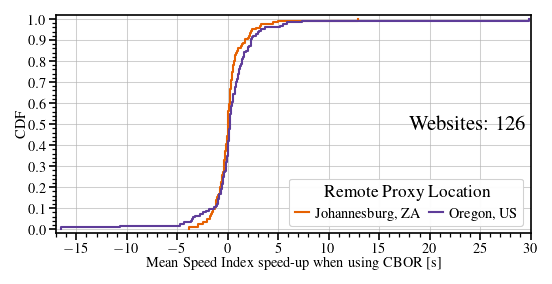

In [3]:
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.0,
    matplotlib.rcParams["figure.figsize"][1] * 6 / 8,
)

df = polars.read_parquet(EVALUATION_DIR / "output-dataset" / "lighthouse.parquet")

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()
stats = None

METRICS = [
    #"first_contentful_paint",
    # "largest_contentful_paint",
    "speed_index",
    # "total_blocking_time",
    # "rtt",
]
METRIC_STYLE = {
    "first_contentful_paint": {}, # {"color": "#5e3c99"},
    "largest_contentful_paint": {}, # {"color": "#b2abd2"},
    "speed_index": {},
    "total_blocking_time": {"color": "#fdb863"},
    "rtt": {},
}
LOCATION_STYLE = {
    "us-west": {"color": "#5e3c99"}, # {"marker": "x"},
    "africa-south": {"color": "#e66101"}, # {"marker": None, "markevery": 5},
}
LOCATIONS = {
    "us-west": "Oregon, US",
    "africa-south": "Johannesburg, ZA",
}

for location in df["extra"].unique().sort():
    for metric in METRICS:
        times = df.filter(~polars.col("packed") & (polars.col("extra") == location)).select(
            ["compress", "domain", "run", metric]
        ).pivot(
            "compress",
            index=["domain", "run"],
            values=[metric]
        ).filter(
            polars.col("true").is_not_null()
            & polars.col("false").is_not_null()
        ).rename(
            {
                "true": "Compressed",
                "false": "Not compressed",
            }
        ).with_columns(
            Difference=polars.col("Not compressed") - polars.col("Compressed")
        ).select(["domain", "Compressed", "Not compressed", "Difference"]).group_by("domain").agg(
            polars.col("Difference").mean().alias("Mean Difference"),
            polars.col("Difference").std().alias("Std. Difference"),
        ).lazy().join(
            polars.scan_csv(EVALUATION_DIR / "tranco_3QL4L.csv", has_header=False, new_columns=["rank", "domain"]),
            on="domain",
        ).collect().sort("Mean Difference")
        # display(times)
        domains = times.select(polars.col("domain").unique()).shape[0]
        # audits = times.shape[0]
        #matplotlib.pyplot.clf()
        display(f"Websites {LOCATIONS[location]}: {domains}")
        #lower_std = ax.ecdf(times["Mean Difference"] - times["Std. Difference"], color="none", linewidth=0)
        #upper_std = ax.ecdf(times["Mean Difference"] + times["Std. Difference"], color="none", linewidth=0)
        #assert (lower_std.get_ydata() == upper_std.get_ydata()).all()
        #ax.fill_betweenx(lower_std.get_ydata(), lower_std.get_xdata(), upper_std.get_xdata(), color=METRIC_COLORS[metric], alpha=0.3)
        cdf = ax.ecdf(times["Mean Difference"], **METRIC_STYLE[metric], **LOCATION_STYLE[location], linewidth=1)
        comp = "Mean Difference"
        stat = polars.DataFrame(
            [
                {
                    "Metric": metric,
                    "Location": location,
                    "min.": times[comp].min(),
                    "max.": times[comp].max(),
                    "mean": times[comp].mean(),
                    "std": times[comp].std(),
                    "median": times[comp].median(),
                }
            ]
        )
        if stats is None:
            stats = stat
        else:
            stats = polars.concat([stats, stat])
display(stats)
ax.set_xlabel(f"Mean Speed Index speed-up when using CBOR [s]")
ax.set_xlim(-17000, 30000)
ax.set_xticks(numpy.arange(-15000, 30100, 5000))
ax.set_xticks(numpy.arange(-17000, 30100, 1000), minor=True)
ax.grid()
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x / 1000.0:.0f}$"))
ax.set_ylabel("CDF")
ax.set_ylim(-0.02, 1.02)
ax.set_yticks(numpy.arange(0, 1.1, 0.1))
ax.set_yticks(numpy.arange(0, 1.02, 0.02), minor=True)
ax.text(
    0.99,
    0.5,
    f"Websites: {domains}", # (successful audits / site: {audits / domains:.2f} / 3.00)", 
    ha="right",
    va="center",
    transform=ax.transAxes,
)
# handles = [
#     matplotlib.lines.Line2D([0], [0], label=metric.replace("_", " ").title(), **METRIC_STYLE[metric])
#     for metric in METRICS
# ]
# legend_metrics = ax.legend(loc="center right", handles=handles, title="Lighthouse Metric", ncol=2)
# ax.add_artist(legend_metrics)
handles = [
    matplotlib.lines.Line2D([0], [0], label=LOCATIONS[loc], **LOCATION_STYLE[loc])
    for loc in df["extra"].unique().sort()
]
legend_location = ax.legend(loc="lower right", handles=handles, title="Remote Proxy Location", ncol=2)
ax.add_artist(legend_location)
filepath = EVALUATION_DIR / "plots" / "lighthouse-cdf.pdf"
display(
    Markdown(
        f"## [Lighthouse Metrics (CDF)]({str(filepath.relative_to(pathlib.Path.cwd()))})"
    )
)
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()

metric,location,min.,max.,mean,std.,median
str,str,f64,f64,f64,f64,f64
"""first_contentful_paint""","""africa-south""",-1322.936183,2036.6258,36.268561,459.036316,8.73755
"""largest_contentful_paint""","""africa-south""",-8913.13038,7051.62718,25.584722,1578.099094,31.1827
"""speed_index""","""africa-south""",-3802.417477,12929.112287,163.79012,1718.764186,36.90194
"""total_blocking_time""","""africa-south""",-1015.354,631.7656,-8.885807,165.507025,-0.3
"""rtt""","""africa-south""",-200.783984,419.4418,1.509345,46.822875,-0.024


metric,location,min.,max.,mean,std.,median
str,str,f64,f64,f64,f64,f64
"""first_contentful_paint""","""us-west""",-3888.525667,5431.416685,148.629695,945.946704,67.748458
"""largest_contentful_paint""","""us-west""",-40976.847038,41053.1415,-194.318221,5913.974672,28.343188
"""speed_index""","""us-west""",-16553.503406,29826.342939,413.616575,3662.98522,220.488685
"""total_blocking_time""","""us-west""",-2432.56215,1477.38433,-120.911606,381.062549,-39.87
"""rtt""","""us-west""",-117.552258,378.027182,7.2634,51.346518,-0.015575


## [Lighthouse Metrics (Box Plot)](06_1evaluation/plots/lighthouse-box.pdf)

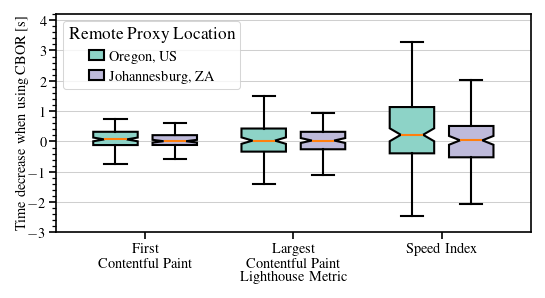

In [4]:
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.0,
    matplotlib.rcParams["figure.figsize"][1] * 6 / 8,
)

df = polars.read_parquet(EVALUATION_DIR / "output-dataset" / "lighthouse.parquet")

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()
stats = None
METRICS = [
    "first_contentful_paint",
    "largest_contentful_paint",
    "speed_index",
    "total_blocking_time",
    "rtt",
]

COLOR_CYCLE=["#e66101", "#5e3c99"]
BOXPLOT_COLORS={
    "us-west": "#8dd3c7",
    "africa-south": "#bebada",
}
ax.set_prop_cycle(cycler.cycler(color=COLOR_CYCLE))

METRIC_XAXIS_LABEL = {
    "first_contentful_paint": "First\nContentful Paint",
    "largest_contentful_paint": "Largest\nContentful Paint",
    "speed_index": "Speed Index",
    "total_blocking_time": "Total\nBlocking Time",
    "rtt": "RTT",
}
LOCATIONS = {
    "us-west": "Oregon, US",
    "africa-south": "Johannesburg, ZA",
}
LOCATION_OFFSET = {
    "us-west": -0.2,
    "africa-south": 0.2,
}
WIDTH = 0.4

for i, location in enumerate(df["extra"].unique().sort()):
    times = df.filter(~polars.col("packed") & (polars.col("extra") == location)).select(
        ["compress", "domain", "run"] + METRICS
    # ).filter(
    #     polars.col("run") != 2
    ).pivot(
        "compress",
        index=["domain", "run"],
        values=METRICS,
    ).with_columns(
        **{
            # ~compressed - compressed
            k: polars.col(f"{k}_false") - polars.col(f"{k}_true")
            for k in METRICS
        }
    ).filter(
        polars.col("first_contentful_paint").is_not_null()
        & polars.col("largest_contentful_paint").is_not_null()
        & polars.col("speed_index").is_not_null()
        & polars.col("total_blocking_time").is_not_null()
        & polars.col("rtt").is_not_null()
    ).select(
        ["domain"] + METRICS
    ).group_by("domain").mean()
    
    stats = polars.DataFrame(
        [
            {
                "metric": k,
                "location": location,
                "min.": times[k].min(),
                "max.": times[k].max(),
                "mean": times[k].mean(),
                "std.": times[k].std(),
                "median": times[k].median(),
            }
            for k in METRICS
        ],
    )

    display(stats)
    # ax.violinplot(
    #     times.select(METRICS).select(polars.exclude(["rtt", "total_blocking_time"])),
    #     numpy.arange(1, len(METRICS) - 1) + LOCATION_OFFSET[location],
    #     showmeans=True,
    #     showmedians=True,
    #     widths=WIDTH,
    # )
    bxplt = ax.boxplot(
        times.select(METRICS).select(polars.exclude(["rtt", "total_blocking_time"])),
        positions=numpy.arange(1, len(METRICS) - 1) + LOCATION_OFFSET[location],
        notch=True,
        widths=WIDTH - .1,
        showfliers=False,
        patch_artist=True,
        #showmeans=True,
        #meanprops={"marker": ".", "markeredgecolor": "black", "markerfacecolor": "none"},
    )
    for patch in bxplt['boxes']:
        patch.set_facecolor(BOXPLOT_COLORS[location])
        patch.set_linewidth(1)
ax.set_axisbelow(True)
ax.grid(axis="y")
ax.set_xlim(0.4, 3.6)
ax.set_xlabel(f"Lighthouse Metric")
ax.set_xticks(range(1, len(METRICS) - 1), [METRIC_XAXIS_LABEL[m] for m in METRICS if m not in ["rtt", "total_blocking_time"]])
ax.set_ylabel(f"Time decrease when using CBOR [s]")
# ax.set_ylim(-42000, 42000)
# ax.set_yticks(numpy.arange(-40000, 42100, 5000))
# ax.set_yticks(numpy.arange(-42000, 42100, 1000), minor=True)
ax.set_ylim(-3000, 4200)
ax.set_yticks(numpy.arange(-3000, 4300, 1000))
ax.set_yticks(numpy.arange(-3000, 4300, 200), minor=True)
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda y, pos: f"${y / 1000.0:.0f}$"))
# handles = [
#     matplotlib.lines.Line2D([0], [0], label=LOCATIONS[loc], color=COLOR_CYCLE[i])
#     for i, loc in enumerate(df["extra"].unique().sort())
# ]
handles = [
    matplotlib.patches.Patch(label=LOCATIONS[loc], facecolor=BOXPLOT_COLORS[loc], edgecolor="black", linewidth=1)
    for loc in reversed(df["extra"].unique().sort())
]
legend_metrics = ax.legend(loc="upper left", handles=handles, title="Remote Proxy Location")
filepath = EVALUATION_DIR / "plots" / "lighthouse-box.pdf"
display(
    Markdown(
        f"## [Lighthouse Metrics (Box Plot)]({str(filepath.relative_to(pathlib.Path.cwd()))})"
    )
)
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()

In [5]:
errors = df.filter(
    polars.col("error").is_not_null()
).select(
    ["domain", "run", "extra", "compress", "error"]
)
with polars.Config(fmt_str_lengths=df["error"].str.len_chars().max()): #, tbl_rows=162):
    display(
        errors.pivot(
            "run",
            index=["domain", "compress", "extra"],
            values="error"
        ).rename(
            {
                str(k): f"run_{k:02d}"
                for k in range(1, df["run"].max() + 1)
            }
        ).lazy().join(
            polars.scan_csv(EVALUATION_DIR / "tranco_3QL4L.csv", has_header=False, new_columns=["rank", "domain"]),
            on="domain",
        ).select(
            ["rank", "domain", "extra", "compress"] + [f"run_{k:02d}" for k in range(1, df["run"].max() + 1)]
        ).sort(["rank", "extra", "compress"]).collect()
    )
error_summary = errors.group_by("error").agg(
    polars.col("error").len().alias("count"),
).with_columns(
    polars.col("error").str.replace(
        r"ERRORED_DOCUMENT_REQUEST \(Status: ([0-9]+)\)", "${1}"
    ).map_elements(
        lambda x: (
            f"HTTP error: {http.HTTPStatus(int(x)).phrase} ({x})"
            if int(x) in http.HTTPStatus
            else f"HTTP error: CDN Connection Timed Out ({x})"
        ) if x.isdigit() else x,
        return_dtype=polars.String,
    )
).with_columns(
    error_ratio=(polars.col("count") / df["domain"].len())
)
with polars.Config(fmt_str_lengths=error_summary["error"].str.len_chars().max()):
    display(error_summary)

rank,domain,extra,compress,run_01,run_02,run_03,run_04,run_05
i64,str,str,bool,str,str,str,str,str
2,"""gtld-servers.net""","""africa-south""",false,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR"""
2,"""gtld-servers.net""","""africa-south""",true,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR"""
2,"""gtld-servers.net""","""us-west""",false,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR"""
2,"""gtld-servers.net""","""us-west""",true,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR"""
3,"""gstatic.com""","""africa-south""",false,"""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)""","""ERRORED_DOCUMENT_REQUEST (Status: 404)"""
…,…,…,…,…,…,…,…,…
999999,"""c2x.com.br""","""us-west""",true,"""NO_FCP""","""NO_FCP""","""NO_FCP""","""NO_FCP""","""NO_FCP"""
1000000,"""aaacompany.net""","""africa-south""",false,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR"""
1000000,"""aaacompany.net""","""africa-south""",true,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR"""


error,count,error_ratio
str,u64,f64
"""HTTP error: CDN Connection Timed Out (522)""",4,0.001038
"""HTTP error: Bad Request (400)""",19,0.00493
"""CHROME_INTERSTITIAL_ERROR""",675,0.175143
"""NOT_HTML""",19,0.00493
"""HTTP error: Forbidden (403)""",88,0.022833
"""HTTP error: Not Found (404)""",99,0.025688
"""NO_FCP""",270,0.070057
"""HTTP error: Unavailable For Legal Reasons (451)""",9,0.002335
"""HTTP error: Bad Gateway (502)""",292,0.075765


In [6]:
lf = df.select(["domain", "extra", "run", "error"]).group_by(["domain", "extra"]).agg(polars.col("run").len().alias("runs"), polars.col("error")).with_columns(
    polars.col("runs") / 2   # compressed and uncompressed runs are counted here together so devide by 2
).lazy().join(
    polars.scan_csv(EVALUATION_DIR / "tranco_3QL4L.csv", has_header=False, new_columns=["rank", "domain"]),
    on="domain",
).sort(["rank", "extra"]).select(["rank", "domain", "extra", "runs", "error"])
with polars.Config(tbl_rows=df.shape[0]):
    display(lf.collect())

rank,domain,extra,runs,error
i64,str,str,f64,list[str]
1,"""google.com""","""africa-south""",5.0,"[null, null, … null]"
1,"""google.com""","""us-west""",5.0,"[null, null, … null]"
2,"""gtld-servers.net""","""africa-south""",5.0,"[""CHROME_INTERSTITIAL_ERROR"", ""CHROME_INTERSTITIAL_ERROR"", … ""CHROME_INTERSTITIAL_ERROR""]"
2,"""gtld-servers.net""","""us-west""",5.0,"[""CHROME_INTERSTITIAL_ERROR"", ""CHROME_INTERSTITIAL_ERROR"", … ""CHROME_INTERSTITIAL_ERROR""]"
3,"""gstatic.com""","""africa-south""",5.0,"[""ERRORED_DOCUMENT_REQUEST (Status: 404)"", ""ERRORED_DOCUMENT_REQUEST (Status: 404)"", … ""ERRORED_DOCUMENT_REQUEST (Status: 404)""]"
3,"""gstatic.com""","""us-west""",5.0,"[""ERRORED_DOCUMENT_REQUEST (Status: 404)"", ""ERRORED_DOCUMENT_REQUEST (Status: 404)"", … ""ERRORED_DOCUMENT_REQUEST (Status: 404)""]"
4,"""facebook.com""","""africa-south""",5.0,"[null, null, … null]"
4,"""facebook.com""","""us-west""",5.0,"[null, null, … null]"
5,"""cloudflare.com""","""africa-south""",5.0,"[null, null, … null]"


In [7]:
lhtss = polars.scan_parquet(
    EVALUATION_DIR / "output-dataset" / "lighthouse.parquet"
).select("lighthouse_timestamp").unique().collect()["lighthouse_timestamp"].implode()

for proxy in ["local", "remote"]:
    with subprocess.Popen(
        "awk -F'\t' '$1 ~ /ROW/ || "
        "$1 ~ /marker/ {print $0}' \"${EVALUATION_DIR}/output-dataset/"
        f"docker-compose-{proxy}-\"*.log",
        stdout=subprocess.PIPE,
        shell=True
    ) as proc:
        polars.scan_csv(
            proc.stdout.read(),
            separator="\t",
            infer_schema=False,  # do not infer schema as header might repeat (see filter below)
        ).select(
            polars.exclude("^.+marker$")
        ).filter(
            polars.col("timestamp") != "timestamp"  # skip header repetitions
        ).with_columns(
            polars.from_epoch(
                polars.col("lhts").cast(polars.Int32),
                time_unit="s",
            ).dt.convert_time_zone(time_zone="Europe/Berlin"),
        ).filter(
            polars.col("lhts").is_in(lhtss)
        ).with_columns(
            polars.from_epoch(
                polars.col("timestamp").cast(polars.Float64)
            ).dt.convert_time_zone(time_zone="Europe/Berlin"),
            polars.col("domain_rank").cast(polars.Int32),
            polars.col("run").cast(polars.Int8),
            polars.col("convert").str.to_lowercase() == "true",
            polars.col("packed").str.to_lowercase() == "true",
            polars.col("response_status").cast(polars.Int16),
            polars.col("orig_body_length").cast(polars.Int64),
            polars.col("orig_content_length").cast(polars.Int64),
            polars.col("new_body_length").cast(polars.Int64),
            polars.col("query_missing").str.to_lowercase() == "true",
            polars.col("handler_time").cast(polars.Float64),
        ).sink_parquet(
            EVALUATION_DIR / "output-dataset" / f"mitmproxy-{proxy}.parquet",
            compression="zstd",
            compression_level=22,
        )

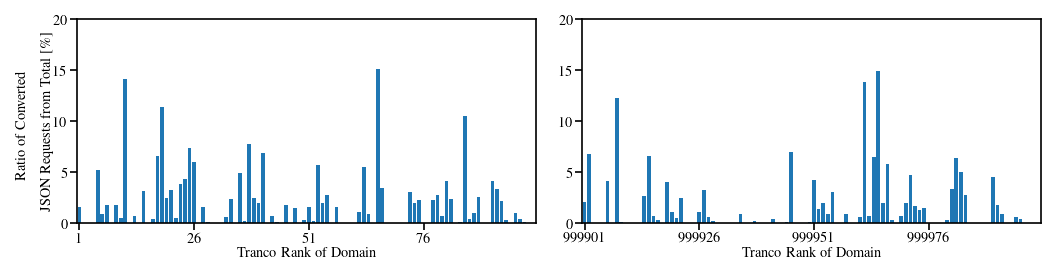

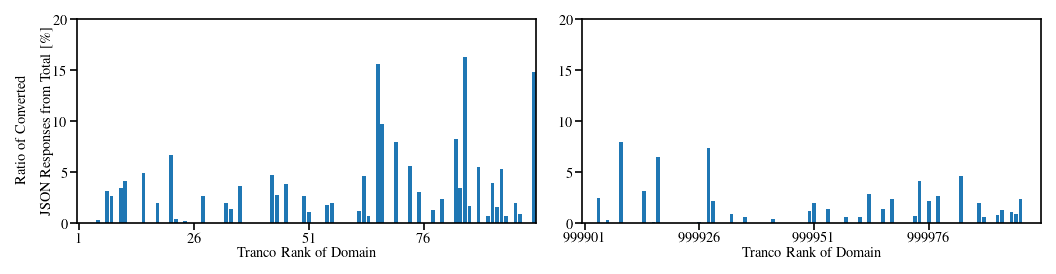

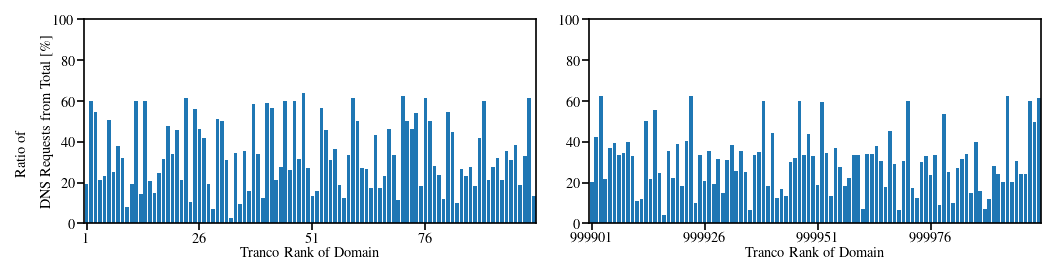

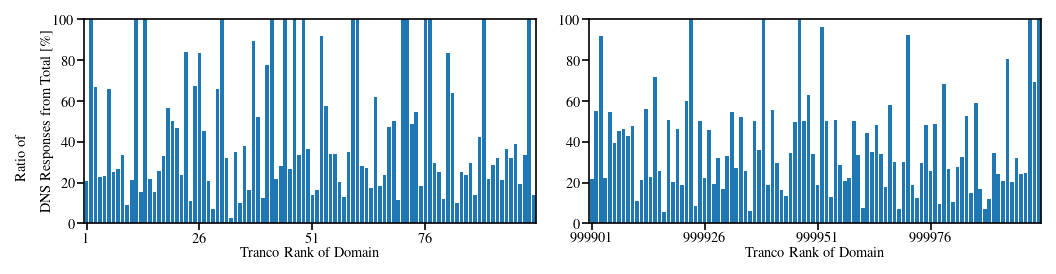

In [8]:
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_fullwidth_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.0,
    matplotlib.rcParams["figure.figsize"][1] * 7 / 8,
)

logs_lf = polars.scan_parquet(
    EVALUATION_DIR / "output-dataset" / "mitmproxy-local.parquet"
).filter(polars.col("domain").is_not_null() & ~polars.col("packed"))

requests = logs_lf.filter(polars.col("response_status").is_null())
responses = logs_lf.filter(polars.col("response_status").is_not_null())
converted_reqs = requests.filter(polars.col("msg").str.starts_with("Converted "))
converted_resps = responses.filter(polars.col("msg").str.starts_with("Converted "))
converted_json_reqs = converted_reqs.filter(polars.col("msg").str.contains("JSON"))
converted_json_resps = converted_resps.filter(polars.col("msg").str.contains("JSON"))
converted_dns_reqs = converted_reqs.filter(polars.col("msg").str.contains("DNS"))
converted_dns_resps = converted_resps.filter(polars.col("msg").str.contains("DNS"))

stats_df = requests.group_by(
    ["domain", "domain_rank", "run", "convert"]
).agg(reqs_count=polars.col("msg").len()).join(
    responses.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_reqs.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(converted_reqs_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_resps.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(converted_resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_json_reqs.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(json_reqs_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_json_resps.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(json_resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_dns_reqs.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(dns_reqs_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_dns_resps.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(dns_resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).sort(["domain_rank", "run", "convert"]).with_columns(
    polars.col("converted_reqs_count").fill_null(0) / polars.col("reqs_count"),
    polars.col("converted_resps_count").fill_null(0) / polars.col("resps_count"),
    polars.col("json_reqs_count").fill_null(0) / polars.col("reqs_count"),
    polars.col("json_resps_count").fill_null(0) / polars.col("resps_count"),
    polars.col("dns_reqs_count").fill_null(0) / polars.col("reqs_count"),
    polars.col("dns_resps_count").fill_null(0) / polars.col("resps_count"),
).group_by(
    ["domain", "domain_rank", "convert"]
).mean().select(polars.exclude("run")).sort(["domain_rank", "convert"]).collect()

msg_diff = stats_df.filter(polars.col("convert")).select(
    ["domain", "domain_rank", "reqs_count", "resps_count"]
).join(
    stats_df.filter(~polars.col("convert")).select(
        ["domain", "domain_rank", "reqs_count", "resps_count"]
    ),
    ["domain", "domain_rank"],
    "right",
).with_columns(
    reqs_diff=polars.col("reqs_count") - polars.col("reqs_count_right"),
    resps_diff=polars.col("resps_count") - polars.col("resps_count_right"),
)
HUMAN = {
    "reqs": "Requests",
    "resps": "Responses",
}

stats_df = stats_df.filter(polars.col("convert") == True)

for msg in ["reqs", "resps"]:
    fig, axs = matplotlib.pyplot.subplots(ncols=2)
    fig.set_dpi(150)
    for i, (filt, ax) in enumerate(zip((polars.col("domain_rank") <= 100, polars.col("domain_rank") > 100), axs)):
        ax.bar(stats_df.filter(filt)["domain_rank"], stats_df.filter(filt)[f"json_{msg}_count"])
        ax.set_xlim(stats_df.filter(filt)["domain_rank"].min() - 0.5, stats_df.filter(filt)["domain_rank"].max() + 0.5)
        ax.set_xticks(
            numpy.arange(
                stats_df.filter(filt)["domain_rank"].min(),
                stats_df.filter(filt)["domain_rank"].max() + 1,
                25,
            )
        )
        ax.set_xlabel("Tranco Rank of Domain")
        ax.set_ylim(0, 0.2)
        ax.ticklabel_format(useOffset=False)
        ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        if i == 0:
            ax.set_ylabel(fr"Ratio of Converted\\JSON {HUMAN[msg]} from Total [\%]")
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:.0f}$"))
    fig.tight_layout()
    matplotlib.pyplot.show()


for msg in ["reqs", "resps"]:
    fig, axs = matplotlib.pyplot.subplots(ncols=2)
    fig.set_dpi(150)
    for i, (filt, ax) in enumerate(zip((polars.col("domain_rank") <= 100, polars.col("domain_rank") > 100), axs)):
        ax.bar(stats_df.filter(filt)["domain_rank"], stats_df.filter(filt)[f"dns_{msg}_count"])
        ax.set_xlim(stats_df.filter(filt)["domain_rank"].min() - 0.5, stats_df.filter(filt)["domain_rank"].max() + 0.5)
        ax.set_xticks(
            numpy.arange(
                stats_df.filter(filt)["domain_rank"].min(),
                stats_df.filter(filt)["domain_rank"].max() + 1,
                25,
            )
        )
        ax.set_xlabel("Tranco Rank of Domain")
        ax.set_ylim(0, 1)
        ax.ticklabel_format(useOffset=False)
        ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        if i == 0:
            ax.set_ylabel(fr"Ratio of\\DNS {HUMAN[msg]} from Total [\%]")
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:.0f}$"))
    fig.tight_layout()
    matplotlib.pyplot.show()

domain,domain_rank,reqs_byte_savings,resps_byte_savings
str,i32,f64,f64


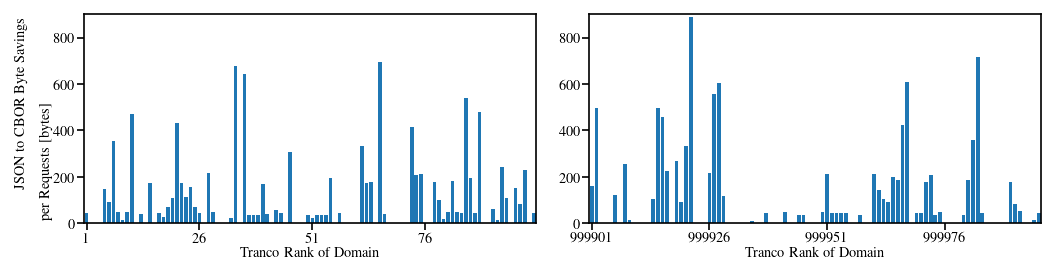

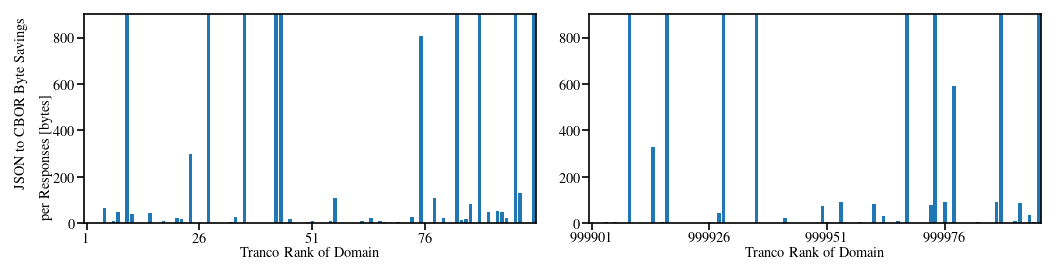

In [9]:
json_byte_savings = converted_json_reqs.with_columns(
    byte_savings=polars.col("orig_body_length") - polars.col("new_body_length"),
).group_by(
    ["domain", "domain_rank"]
).agg(polars.col("byte_savings").mean().alias("reqs_byte_savings")).join(
    converted_json_resps.with_columns(
        byte_savings=polars.col("new_body_length") - polars.col("orig_body_length"),
    ).group_by(
        ["domain", "domain_rank"]
    ).agg(polars.col("byte_savings").mean().alias("resps_byte_savings")),
    ["domain", "domain_rank"],
    "full"
).with_columns(
    domain_rank=polars.when(
        polars.col("domain_rank").is_null()
    ).then(
        polars.col("domain_rank_right")
    ).otherwise(
        polars.col("domain_rank")
    ),
    domain=polars.when(
        polars.col("domain").is_null()
    ).then(
        polars.col("domain_right")
    ).otherwise(
        polars.col("domain")
    ),
).select(polars.exclude("^.*_right$")).sort("domain_rank").collect()
display(json_byte_savings.filter(polars.col("reqs_byte_savings") > 1500))

for msg in ["reqs", "resps"]:
    fig, axs = matplotlib.pyplot.subplots(ncols=2)
    fig.set_dpi(150)
    for i, (filt, ax) in enumerate(zip((polars.col("domain_rank") <= 100, polars.col("domain_rank") > 100), axs)):
        ax.bar(json_byte_savings.filter(filt)["domain_rank"], json_byte_savings.filter(filt)[f"{msg}_byte_savings"])
        ax.set_xlim(json_byte_savings.filter(filt)["domain_rank"].min() - 0.5, json_byte_savings.filter(filt)["domain_rank"].max() + 0.5)
        ax.set_xticks(
            numpy.arange(
                json_byte_savings.filter(filt)["domain_rank"].min(),
                json_byte_savings.filter(filt)["domain_rank"].max() + 1,
                25,
            )
        )
        ax.set_xlabel("Tranco Rank of Domain")
        ax.set_ylim(0, 900)
        ax.ticklabel_format(useOffset=False)
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        if i == 0:
            ax.set_ylabel(fr"JSON to CBOR Byte Savings\\per {HUMAN[msg]} [bytes]")
    fig.tight_layout()
    matplotlib.pyplot.show()

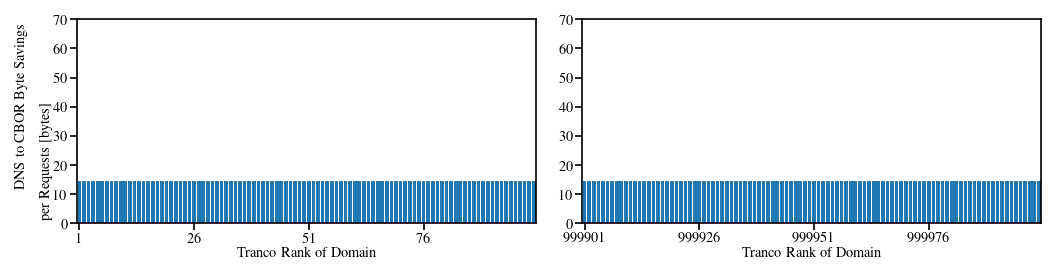

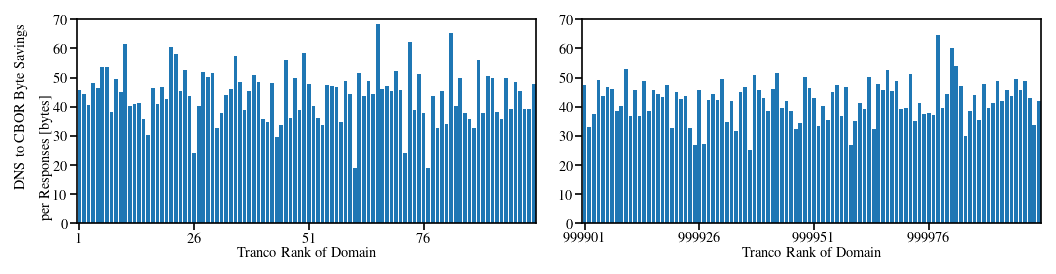

In [10]:
dns_byte_savings = converted_dns_reqs.with_columns(
    byte_savings=polars.col("orig_body_length") - polars.col("new_body_length"),
).group_by(
    ["domain", "domain_rank"]
).agg(polars.col("byte_savings").mean().alias("reqs_byte_savings")).join(
    converted_dns_resps.with_columns(
        byte_savings=polars.col("new_body_length") - polars.col("orig_body_length"),
    ).group_by(
        ["domain", "domain_rank"]
    ).agg(polars.col("byte_savings").mean().alias("resps_byte_savings")),
    ["domain", "domain_rank"],
    "full"
).with_columns(
    domain_rank=polars.when(
        polars.col("domain_rank").is_null()
    ).then(
        polars.col("domain_rank_right")
    ).otherwise(
        polars.col("domain_rank")
    ),
    domain=polars.when(
        polars.col("domain").is_null()
    ).then(
        polars.col("domain_right")
    ).otherwise(
        polars.col("domain")
    ),
).select(polars.exclude("^.*_right$")).sort("domain_rank").collect()

for msg in ["reqs", "resps"]:
    fig, axs = matplotlib.pyplot.subplots(ncols=2)
    fig.set_dpi(150)
    for i, (filt, ax) in enumerate(zip((polars.col("domain_rank") <= 100, polars.col("domain_rank") > 100), axs)):
        ax.bar(dns_byte_savings.filter(filt)["domain_rank"], dns_byte_savings.filter(filt)[f"{msg}_byte_savings"])
        ax.set_xlim(dns_byte_savings.filter(filt)["domain_rank"].min() - 0.5, dns_byte_savings.filter(filt)["domain_rank"].max() + 0.5)
        ax.set_xticks(
            numpy.arange(
                dns_byte_savings.filter(filt)["domain_rank"].min(),
                dns_byte_savings.filter(filt)["domain_rank"].max() + 1,
                25,
            )
        )
        ax.set_xlabel("Tranco Rank of Domain")
        ax.set_ylim(0, 70)
        ax.ticklabel_format(useOffset=False)
        ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        if i == 0:
            ax.set_ylabel(fr"DNS to CBOR Byte Savings\\per {HUMAN[msg]} [bytes]")
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
    fig.tight_layout()
    matplotlib.pyplot.show()

In [11]:
df.filter(df["extra"] == "us-west").sort("lighthouse_timestamp")

domain,run,compress,packed,lighthouse_timestamp,extra,rtt,first_contentful_paint,largest_contentful_paint,speed_index,total_blocking_time,cumulative_layout_shift,error,filename
str,i64,bool,bool,"datetime[μs, Europe/Berlin]",str,f64,f64,f64,f64,f64,f64,str,str
"""google.com""",1,true,false,2026-05-04 13:02:05 CEST,"""us-west""",0.637,3321.13,9571.13,8401.660916,526.5,0.0,null,"""lighthouse-run-google.com-001-…"
"""gtld-servers.net""",1,true,false,2026-05-04 13:02:27 CEST,"""us-west""",null,null,null,null,null,null,"""CHROME_INTERSTITIAL_ERROR""","""lighthouse-run-gtld-servers.ne…"
"""gstatic.com""",1,true,false,2026-05-04 13:02:36 CEST,"""us-west""",null,null,null,null,null,null,"""ERRORED_DOCUMENT_REQUEST (Stat…","""lighthouse-run-gstatic.com-001…"
"""facebook.com""",1,true,false,2026-05-04 13:02:47 CEST,"""us-west""",0.586,7563.1955,7755.9915,11048.863844,144.0,0.021733,null,"""lighthouse-run-facebook.com-00…"
"""cloudflare.com""",1,true,false,2026-05-04 13:03:18 CEST,"""us-west""",23.58801,5378.755,19963.496,17643.051912,1653.0,0.014164,null,"""lighthouse-run-cloudflare.com-…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""cloud.microsoft""",5,false,false,2026-05-05 07:38:04 CEST,"""us-west""",0.545,7596.861,8892.501,16460.778871,226.5,0.0,null,"""lighthouse-run-cloud.microsoft…"
"""googledomains.com""",5,false,false,2026-05-05 07:38:39 CEST,"""us-west""",0.267,4732.446,4732.446,6662.59311,0.0,0.001162,null,"""lighthouse-run-googledomains.c…"
"""cloudflare.net""",5,false,false,2026-05-05 07:38:57 CEST,"""us-west""",0.214,7806.3955,8730.2465,18491.081596,128.5,0.00046,null,"""lighthouse-run-cloudflare.net-…"
